<p style="text-align: center">
<img src="../../../assets/images/dtlogo.png" alt="Duckietown" width="50%">
</p>

# 🚙 💻 03 - Wheel Encoders Tutorial

Before we can estimate where the robot is, we need to know how much each wheel has turned.
That is exactly what **wheel encoders** tell us.

In this notebook you will learn:
- What a wheel encoder is and how it produces data
- What a **tick** is and what it represents physically
- How ticks accumulate over time and relate to wheel rotation

---
## 1. What is a wheel encoder?

A wheel encoder is a sensor that measures how much a wheel has rotated.
The Duckiebot uses **Hall-effect encoders**: small magnets are embedded around the inside of the wheel hub, and a fixed magnetic sensor sits next to them.
Every time the wheel rotates enough for one magnet to pass the sensor, the encoder fires a **pulse** — we call each pulse a **tick**.

```
  Wheel hub (side view)
  ┌──────────────────────┐
  │  N  .  .  .  S  .  . │  ← magnets spaced evenly around the hub
  └──────────────────────┘
          ↑
       [sensor]  → fires 1 tick each time a magnet passes
```

The Duckiebot's encoders have a **resolution of 135 ticks per full revolution**.
This means that for every complete 360° rotation of the wheel, the encoder emits exactly 135 ticks.
Each tick therefore corresponds to a wheel rotation of:

$$\alpha = \frac{2\pi}{N_{tot}} = \frac{2\pi}{135} \approx 2.67°$$

---
## 2. How ticks accumulate

The encoder keeps a **running cumulative count** — it never resets on its own.

- Rolling **forward** → tick count **increases**
- Rolling **backward** → tick count **decreases**

The plot below simulates a wheel spinning forward for 2 seconds then reversing for 1 second.

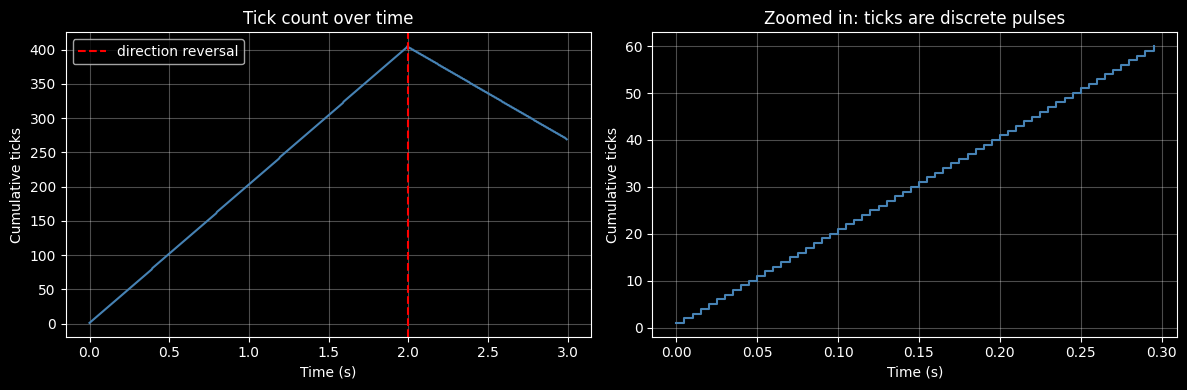

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_tot = 135
alpha = 2 * np.pi / N_tot

def wheel_speed(t):
    return 1.5 if t < 2.0 else -1.0   # rev/s

dt, duration = 0.005, 3.0
times, ticks = [], []
angle = 0.0

for i in range(int(duration / dt)):
    t = i * dt
    angle += wheel_speed(t) * 2 * np.pi * dt
    times.append(t)
    ticks.append(int(angle / alpha))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(times, ticks, color='steelblue')
axes[0].axvline(2.0, color='red', linestyle='--', label='direction reversal')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Cumulative ticks')
axes[0].set_title('Tick count over time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoom in to show discrete steps
zoom = int(0.3 / dt)
axes[1].step(times[:zoom], ticks[:zoom], where='post', color='steelblue')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Cumulative ticks')
axes[1].set_title('Zoomed in: ticks are discrete pulses')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Notice two things:
- The tick count is a **staircase** (discrete steps), not a smooth curve — it only jumps when a magnet passes the sensor.
- After the direction reversal the count starts **decreasing**, reflecting backward motion.

---
## 3. From ticks to wheel rotation angle

The odometry algorithm works with **per-step changes**, not the raw cumulative count.
At each time step we compute $\Delta\phi$ — how much the wheel rotated since the last reading:

$$\Delta\phi = \frac{\text{ticks}_{\text{current}} - \text{ticks}_{\text{prev}}}{N_{tot}} \cdot 2\pi$$

The plot below shows $\Delta\phi$ computed at 10 Hz from the same forward/backward scenario.

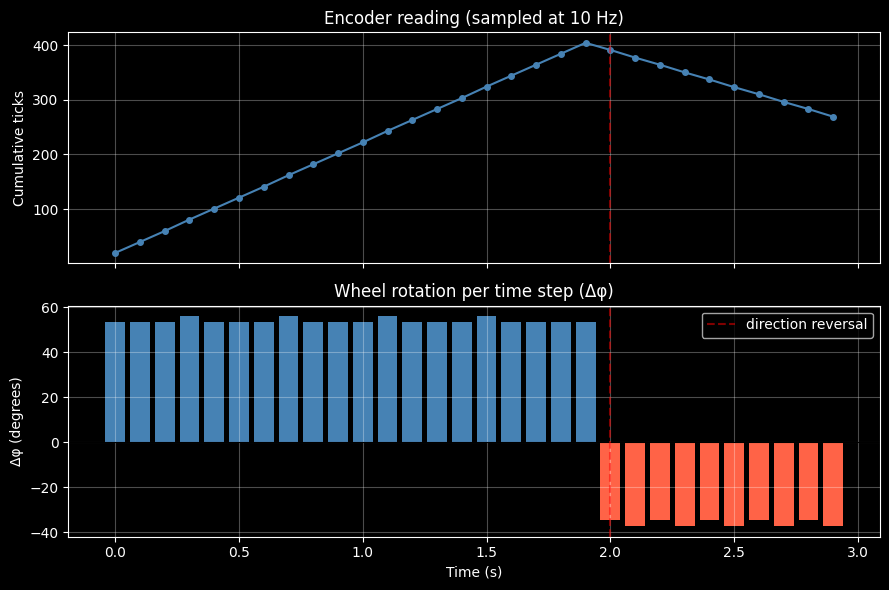

In [2]:
sample_dt = 0.1
sample_times = np.arange(0, duration, sample_dt)

angle_acc, prev_tick = 0.0, 0
delta_phis, tick_samples = [], []

for t in sample_times:
    angle_acc += wheel_speed(t) * 2 * np.pi * sample_dt
    current_tick = int(angle_acc / alpha)
    delta_phis.append(np.rad2deg((current_tick - prev_tick) / N_tot * 2 * np.pi))
    tick_samples.append(current_tick)
    prev_tick = current_tick

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(sample_times, tick_samples, 'o-', color='steelblue', markersize=4)
axes[0].axvline(2.0, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Cumulative ticks')
axes[0].set_title('Encoder reading (sampled at 10 Hz)')
axes[0].grid(True, alpha=0.3)

axes[1].bar(sample_times, delta_phis, width=0.08,
            color=['steelblue' if d >= 0 else 'tomato' for d in delta_phis])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(2.0, color='red', linestyle='--', alpha=0.5, label='direction reversal')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Δφ (degrees)')
axes[1].set_title('Wheel rotation per time step (Δφ)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Blue bars = forward rotation, red bars = backward rotation. This $\Delta\phi$ value — computed independently for each wheel — is the direct input to the odometry equations you will implement next.

---
## 4. Summary

| Concept | Value |
|---|---|
| Encoder type | Hall-effect (incremental) |
| Resolution $N_{tot}$ | 135 ticks / revolution |
| Angle per tick $\alpha$ | $2\pi / 135 \approx 2.67°$ |
| Tick direction | + forward, − backward |
| Key quantity for odometry | $\Delta\phi = \frac{\Delta\text{ticks}}{N_{tot}} \cdot 2\pi$ |

The encoder only tells us how much each wheel has rotated — not where the robot is.
Turning those rotations into a position estimate is the job of **odometry**, which you will implement in the next notebook.

➡️ Continue to [04 - Odometry Activity](../04-Odometry/odometry_activity.ipynb)